# KYC Portfolio Analysis with Pandas

##### Projeto de portfólio com foco em análise exploratória e priorização simples de clientes

# Objetivo

Analisar uma base simulada de clientes KYC para identificar perfis com maior criticidade operacional, com base em status cadastral, pendências documentais, tempo desde a última revisão e outros indicadores simples.

# Pergunta de negócio

Quais clientes ou grupos apresentam maior atenção no processo de KYC com base em status, pendências e tempo desde a última revisão?

In [1]:
#Carregar pacotes principais

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set()
pd.set_option('display.max_columns', None)

In [2]:
# Instala o pacote watermark. 
!pip install -q -U watermark

In [3]:
# Versões dos pacotes usados neste jupyter notebook
%reload_ext watermark
%watermark -a "Gustavo Henrique Barbosa"

Author: Gustavo Henrique Barbosa



### Criação da base simulada

In [4]:
# Criar base de dados fictícios
np.random.seed(42)

n = 1000

df = pd.DataFrame({
    'client_id': range(1, n + 1),
    'client_type': np.random.choice(['Individual', 'Corporate'], n, p=[0.65, 0.35]),
    'segment': np.random.choice(['Retail', 'Private', 'SME', 'Corporate'], n),
    'product': np.random.choice(['Current Account', 'Credit', 'Investment', 'Trade Finance'], n),
    'country_risk': np.random.choice(['Low', 'Medium', 'High'], n, p=[0.7, 0.2, 0.1]),
    'risk_rating': np.random.choice(['Low', 'Medium', 'High'], n, p=[0.5, 0.35, 0.15]),
    'kyc_status': np.random.choice(['Updated', 'Pending', 'Expired'], n, p=[0.6, 0.25, 0.15]),
    'days_since_last_kyc': np.random.randint(30, 900, n),
    'documents_pending': np.random.randint(0, 6, n),
    'rework_count': np.random.randint(0, 4, n),
    'review_overdue_flag': np.random.choice([0, 1], n, p=[0.75, 0.25])
})

df.head()

,client_id,client_type,segment,product,country_risk,risk_rating,kyc_status,days_since_last_kyc,documents_pending,rework_count,review_overdue_flag
0,1,Individual,SME,Trade Finance,Low,Medium,Updated,80,1,1,0
1,2,Corporate,Corporate,Credit,Low,Medium,Pending,100,1,2,1
2,3,Corporate,Private,Credit,High,Low,Pending,509,5,1,0
3,4,Individual,Corporate,Trade Finance,Low,Medium,Updated,589,3,0,1
4,5,Individual,Corporate,Current Account,Low,Medium,Updated,48,4,3,0


### Visualização inicial da base

In [5]:
df.info()
df.shape
df.head()
df.isnull().sum()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 11 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   client_id            1000 non-null   int64 
 1   client_type          1000 non-null   object
 2   segment              1000 non-null   object
 3   product              1000 non-null   object
 4   country_risk         1000 non-null   object
 5   risk_rating          1000 non-null   object
 6   kyc_status           1000 non-null   object
 7   days_since_last_kyc  1000 non-null   int32 
 8   documents_pending    1000 non-null   int32 
 9   rework_count         1000 non-null   int32 
 10  review_overdue_flag  1000 non-null   int64 
dtypes: int32(3), int64(2), object(6)
memory usage: 74.3+ KB


,client_id,days_since_last_kyc,documents_pending,rework_count,review_overdue_flag
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,500.500000,459.326000,2.446000,1.492000,0.235000
std,288.819436,251.837916,1.697046,1.119459,0.424211
min,1.000000,30.000000,0.000000,0.000000,0.000000
25%,250.750000,240.000000,1.000000,0.000000,0.000000
50%,500.500000,453.500000,2.000000,1.000000,0.000000
75%,750.250000,671.000000,4.000000,2.000000,0.000000
max,1000.000000,899.000000,5.000000,3.000000,1.000000


### Análise exploratória inicial

In [6]:
# Distribuíção por Status
df['kyc_status'].value_counts()

# Distribuíção percentual
df['kyc_status'].value_counts(normalize=True) * 100

kyc_status
Updated    61.3
Pending    24.6
Expired    14.1
Name: proportion, dtype: float64

In [7]:
# Distribuição por segmento
df['segment'].value_counts()

segment
Retail       261
Private      258
Corporate    241
SME          240
Name: count, dtype: int64

In [8]:
# Distribuição por produto
df['product'].value_counts()

product
Trade Finance      266
Credit             258
Current Account    250
Investment         226
Name: count, dtype: int64

In [9]:
# Distribuição por risco do país
df['country_risk'].value_counts()

country_risk
Low       689
Medium    210
High      101
Name: count, dtype: int64

### Agrupamentos com Pandas

In [10]:
# Média de documentos pendentes por produto
df.groupby('product')['documents_pending'].mean().sort_values(ascending=False)

product
Credit             2.531008
Trade Finance      2.481203
Investment         2.477876
Current Account    2.292000
Name: documents_pending, dtype: float64

In [11]:
# Média de dias desde última revisão por segmento
df.groupby('segment')['days_since_last_kyc'].mean().sort_values(ascending=False)

segment
Retail       475.226054
Corporate    457.684647
Private      455.910853
SME          447.354167
Name: days_since_last_kyc, dtype: float64

In [12]:
# Percentual de revisão vencida por produto
(df.groupby('product')['review_overdue_flag'].mean() * 100).sort_values(ascending=False)

product
Current Account    25.600000
Credit             23.255814
Trade Finance      22.932331
Investment         22.123894
Name: review_overdue_flag, dtype: float64

In [13]:
# Quantidade de clientes com KYC expirado por segmento
df[df['kyc_status'] == 'Expired'].groupby('segment')['client_id'].count().sort_values(ascending=False)

segment
Retail       41
Corporate    34
Private      34
SME          32
Name: client_id, dtype: int64

# Criar um score simples com Pandas

In [14]:
df['priority_score'] = 0

df['priority_score'] += np.where(df['kyc_status'] == 'Expired', 3, 0)
df['priority_score'] += np.where(df['days_since_last_kyc'] > 365, 2, 0)
df['priority_score'] += np.where(df['documents_pending'] > 2, 2, 0)
df['priority_score'] += np.where(df['rework_count'] > 1, 1, 0)
df['priority_score'] += np.where(df['country_risk'] == 'High', 2, 0)
df['priority_score'] += np.where(df['review_overdue_flag'] == 1, 2, 0)

In [20]:
# Classificar prioridade

def classify_priority(score):
    if score >= 6:
        return 'High'
    elif score >= 3:
        return 'Medium'
    return 'Low'

df['priority_level'] = df['priority_score'].apply(classify_priority)


In [21]:
df[['client_id', 'priority_score', 'priority_level']].head()

,client_id,priority_score,priority_level
0,1,0,Low
1,2,3,Medium
2,3,6,High
3,4,6,High
4,5,3,Medium


In [22]:
# distribuíção da prioridade
df['priority_level'].value_counts()


priority_level
Medium    540
Low       286
High      174
Name: count, dtype: int64

In [23]:
# Top 10 clientes mais críticos
df.sort_values(by='priority_score', ascending=False).head(10)

,client_id,client_type,segment,product,country_risk,risk_rating,kyc_status,days_since_last_kyc,documents_pending,rework_count,review_overdue_flag,priority_score,priority_level
553,554,Individual,Corporate,Credit,High,Medium,Expired,413,5,0,1,11,High
325,326,Corporate,Retail,Credit,High,Medium,Expired,865,4,3,0,10,High
906,907,Corporate,Corporate,Investment,High,Medium,Expired,507,5,3,0,10,High
569,570,Individual,Retail,Trade Finance,High,High,Expired,713,5,3,0,10,High
404,405,Individual,SME,Current Account,Low,Medium,Expired,590,3,2,1,10,High
203,204,Corporate,SME,Current Account,Low,High,Expired,770,5,2,1,10,High
920,921,Corporate,Retail,Investment,Low,High,Expired,851,5,3,1,10,High
527,528,Individual,Retail,Credit,High,Medium,Expired,649,4,3,0,10,High
509,510,Corporate,Corporate,Current Account,Medium,Low,Expired,849,4,2,1,10,High
83,84,Individual,Private,Current Account,High,Medium,Pending,549,5,3,1,9,High


### Visualizações
#### Gráfico 1 — Distribuição do Status KYC

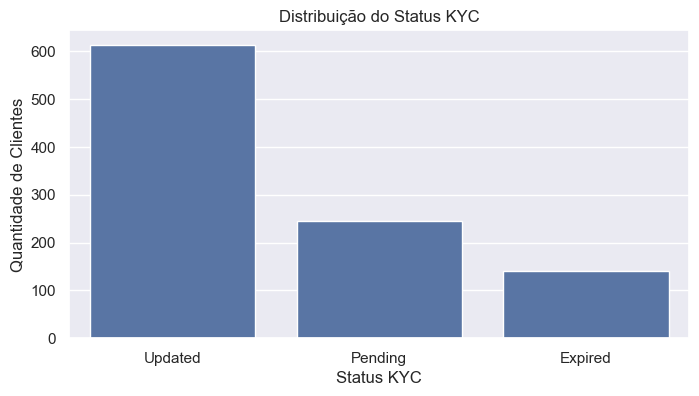

In [24]:
plt.figure(figsize=(8, 4))
sns.countplot(data=df, x='kyc_status')
plt.title('Distribuição do Status KYC')
plt.xlabel('Status KYC')
plt.ylabel('Quantidade de Clientes')
plt.show()    

#### Insight:
A maioria dos clientes está com KYC atualizado, porém há uma parcela relevante em status pendente ou expirado, indicando necessidade de priorização operacional.

#### Gráfico 2 — Distribuição de Prioridade

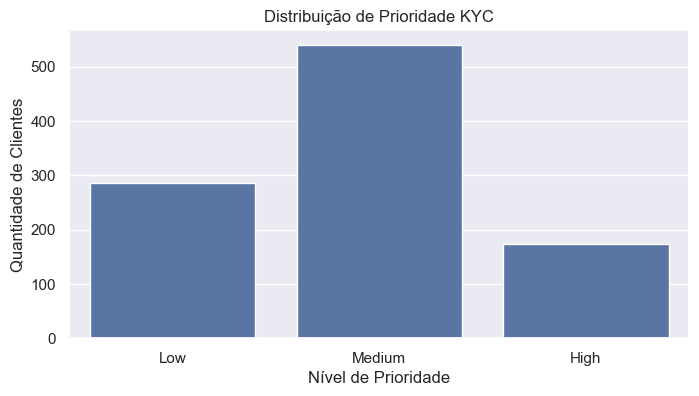

In [25]:
plt.figure(figsize=(8, 4))
sns.countplot(data=df, x='priority_level')
plt.title('Distribuição de Prioridade KYC')
plt.xlabel('Nível de Prioridade')
plt.ylabel('Quantidade de Clientes')
plt.show()

#### Insight:
A distribuição mostra concentração de clientes em níveis médio e alto, sugerindo potencial acúmulo de backlog crítico no processo de KYC.

#### Gráfico 3 — Score Médio por Produto

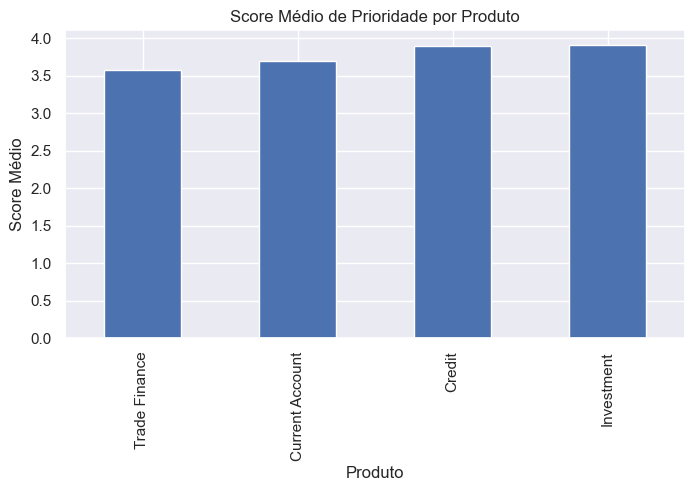

In [26]:
plt.figure(figsize=(8, 4))
df.groupby('product')['priority_score'].mean().sort_values().plot(kind='bar')
plt.title('Score Médio de Prioridade por Produto')
plt.xlabel('Produto')
plt.ylabel('Score Médio')
plt.show()

#### Insight:
Alguns produtos apresentam maior score médio, indicando maior complexidade operacional ou maior exposição ao risco no processo de KYC.

#### Gráfico 4 — Score Médio por Segmento

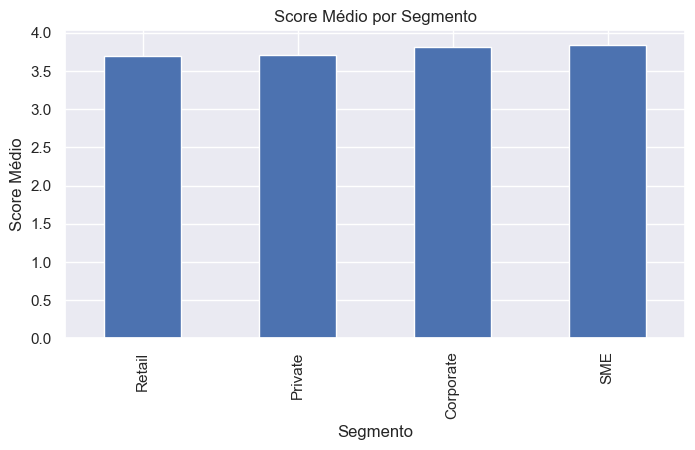

In [27]:
plt.figure(figsize=(8, 4))
df.groupby('segment')['priority_score'].mean().sort_values().plot(kind='bar')
plt.title('Score Médio por Segmento')
plt.xlabel('Segmento')
plt.ylabel('Score Médio')
plt.show()

#### Insight:
Determinados segmentos concentram maior criticidade, o que pode refletir maior complexidade cadastral ou maior volume de pendências.

#### Gráfico 5 — Distribuição de Dias desde a Última Revisão

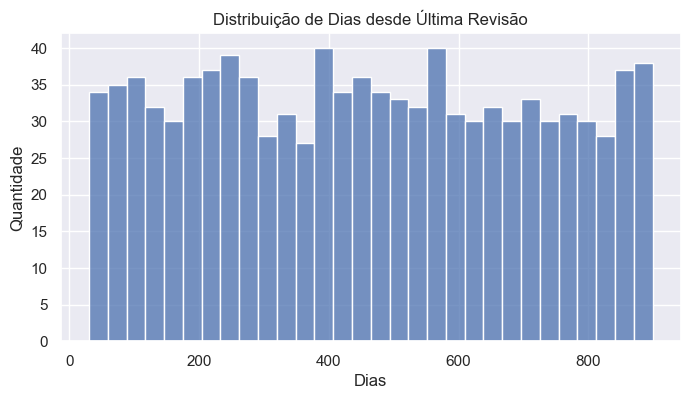

In [28]:
plt.figure(figsize=(8, 4))
sns.histplot(df['days_since_last_kyc'], bins=30)
plt.title('Distribuição de Dias desde Última Revisão')
plt.xlabel('Dias')
plt.ylabel('Quantidade')
plt.show()

#### Insight:
A distribuição evidencia concentração de clientes com longos períodos sem revisão, aumentando o risco de desatualização cadastral.

#### Gráfico 6 — Documentos Pendentes por Prioridade

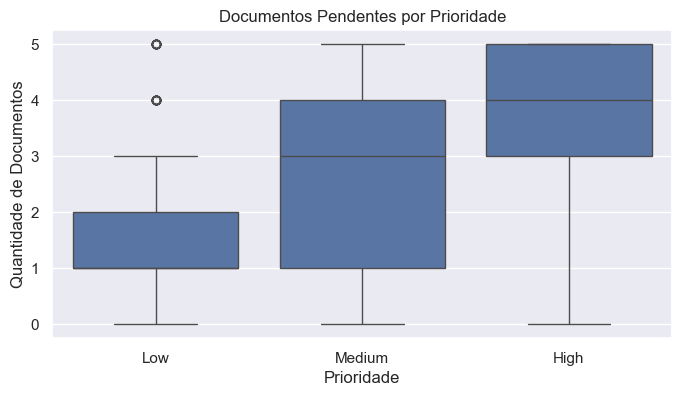

In [29]:
plt.figure(figsize=(8, 4))
sns.boxplot(x='priority_level', y='documents_pending', data=df)
plt.title('Documentos Pendentes por Prioridade')
plt.xlabel('Prioridade')
plt.ylabel('Quantidade de Documentos')
plt.show()

#### Insight:
Clientes classificados como alta prioridade apresentam maior volume de pendências, validando a lógica utilizada na construção do score.

#### Gráfico 7 — Status KYC vs Prioridade

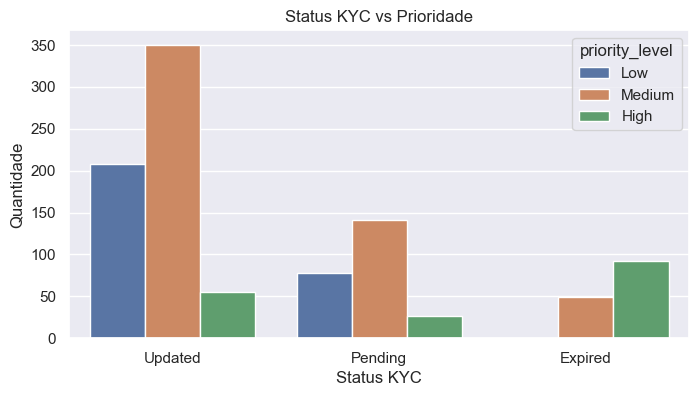

In [30]:
plt.figure(figsize=(8, 4))
sns.countplot(data=df, x='kyc_status', hue='priority_level')
plt.title('Status KYC vs Prioridade')
plt.xlabel('Status KYC')
plt.ylabel('Quantidade')
plt.show()

####  Insight:
Clientes com KYC expirado estão mais concentrados em níveis altos de prioridade, indicando consistência entre status cadastral e criticidade.

#### Gráfico 8 — Heatmap de Correlação

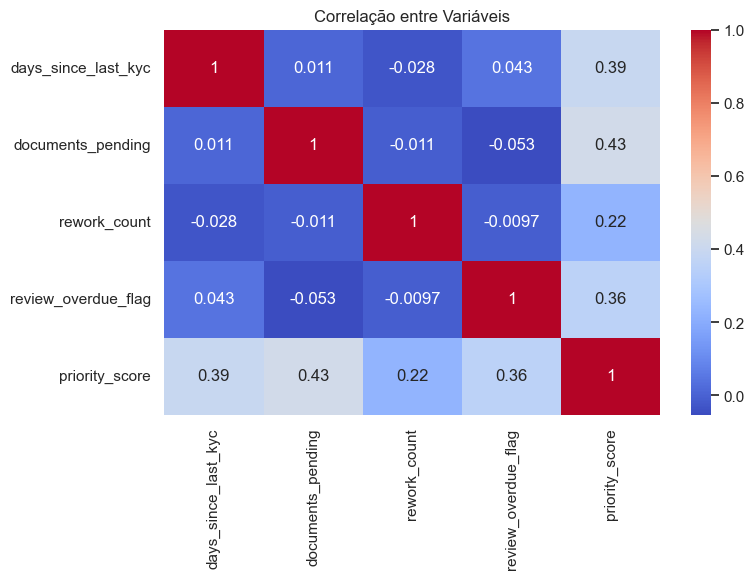

In [31]:
plt.figure(figsize=(8, 5))
corr = df[['days_since_last_kyc', 'documents_pending', 'rework_count', 'review_overdue_flag', 'priority_score']].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title('Correlação entre Variáveis')
plt.show()

#### Insight:
Variáveis como documentos pendentes e tempo desde última revisão apresentam maior correlação com o score, sendo drivers relevantes de priorização.

## Análises finais

In [34]:
# Score médio por produto
df.groupby('product')['priority_score'].mean().sort_values(ascending=False)

product
Investment         3.911504
Credit             3.887597
Current Account    3.696000
Trade Finance      3.575188
Name: priority_score, dtype: float64

In [35]:
# Score médio por segmento
df.groupby('segment')['priority_score'].mean().sort_values(ascending=False)

segment
SME          3.841667
Corporate    3.809129
Private      3.713178
Retail       3.693487
Name: priority_score, dtype: float64

In [36]:
# Quantidade de clientes por prioridade
df['priority_level'].value_counts()

priority_level
Medium    540
Low       286
High      174
Name: count, dtype: int64

In [37]:
# Percentual por prioridade
(df['priority_level'].value_counts(normalize=True) * 100).round(2)

priority_level
Medium    54.0
Low       28.6
High      17.4
Name: proportion, dtype: float64

### Exportação da base tratada

In [38]:
import os

os.makedirs('outputs', exist_ok=True)
df.to_csv('outputs/cleaned_kyc_clients.csv', index=False)

# Conclusão:
A análise mostrou que é possível utilizar Pandas para estruturar uma visão prática, sobre criticidade no processo de KYC. Mesmo com uma abordagem simples, baseada em regras de negócio, o projeto permite identificar clientes com maior necessidade de atenção e apoiar uma priorização mais objetiva e orientada a dados.

# Próximos passos:

##### 1. Criar dashboard em Streamlit
##### 2. Evoluir o score para modelo preditivo
##### 3. Trabalhar com dados reais
##### 4. Adicionar filtros e visualizações executivas

In [39]:
%reload_ext watermark
%watermark -a "Gustavo Henrique Barbosa da Silva"

Author: Gustavo Henrique Barbosa da Silva



In [40]:
%watermark -v -m

Python implementation: CPython
Python version       : 3.13.12
IPython version      : 9.4.0

Compiler    : MSC v.1942 64 bit (AMD64)
OS          : Windows
Release     : 10
Machine     : AMD64
Processor   : Intel64 Family 6 Model 142 Stepping 9, GenuineIntel
CPU cores   : 4
Architecture: 64bit



In [41]:
%watermark --iversions

matplotlib: 3.10.5
numpy     : 2.3.2
pandas    : 2.3.1
seaborn   : 0.13.2



# FIM